# **Task 55: Time Series Analysis with Pandas**

**Student Name:** Qalb E Zahra Mashhadi  
**Program:** NAVTTC — Artificial Intelligence (ML & DL)  

---

## **1. Objective**

The objective of this task is to analyze **electricity consumption** and **renewable energy production (Wind & Solar)** using **Pandas time series tools**. The task focuses on how to **use dates as an index** to **summarize** and **visualize** data efficiently.

---

## **2. Learning Outcomes**

* **DatetimeIndex:** Learned how to use `pd.to_datetime()` to convert strings into dates and set them as **index** for time series analysis.  

* **Resampling:** Learned how to change **data frequency** (e.g., converting **daily data** to **monthly** or **yearly totals**).  

* **Seasonality:** Recognized **recurring patterns** in the data (e.g., higher solar production in summer, lower in winter).  

* **Rolling Windows:** Calculated **moving averages** to **smooth data**, reduce noise, and identify **trends**.  

---

## **3. Conclusion**

**Time Series Analysis** is crucial in **financial markets, weather forecasting, and energy management**. Pandas methods like `resample()` and `rolling()` help extract **meaningful insights** from complex datasets. This analysis revealed that the **share of renewable energy in Germany** has been **increasing over time**.  

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# --- 1. Load Data & Set Index ---
# URL for the sample data (Germany daily electricity)

url = 'https://raw.githubusercontent.com/jenfly/opsd/master/opsd_germany_daily.csv'
opsd_daily = pd.read_csv(url, index_col=0, parse_dates=True)

# Adding helper columns

opsd_daily['Year'] = opsd_daily.index.year
opsd_daily['Month'] = opsd_daily.index.month
opsd_daily['Weekday Name'] = opsd_daily.index.day_name()

In [3]:
# --- 2. Time-Based Indexing ---
# Selecting data for a specific year or month

print("Data for 2017-08-10:")
print(opsd_daily.loc['2017-08-10'])

Data for 2017-08-10:
Consumption     1351.491
Wind             100.274
Solar              71.16
Wind+Solar       171.434
Year                2017
Month                  8
Weekday Name    Thursday
Name: 2017-08-10 00:00:00, dtype: object


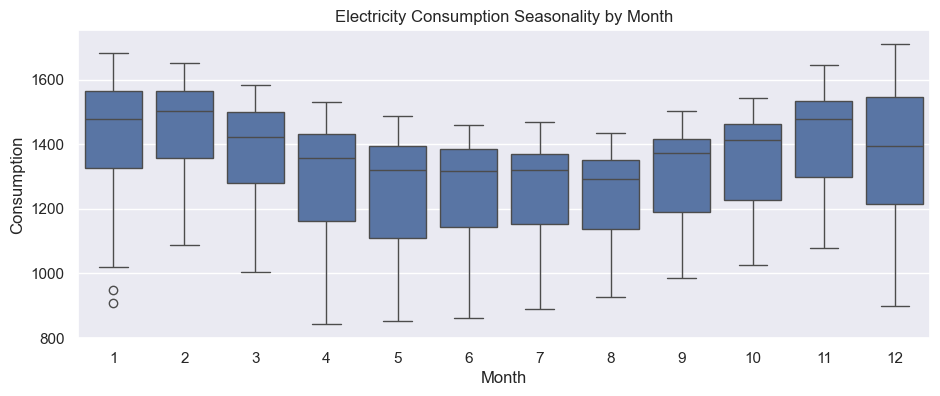

In [4]:
# --- 3. Visualizing Seasonality (Box Plots) ---

sns.set(rc={'figure.figsize':(11, 4)})
sns.boxplot(data=opsd_daily, x='Month', y='Consumption')
plt.title('Electricity Consumption Seasonality by Month')
plt.show()

In [5]:
# --- 4. Resampling (Downsampling to Weekly Mean) ---

data_columns = ['Consumption', 'Wind', 'Solar']
opsd_weekly_mean = opsd_daily[data_columns].resample('W').mean()

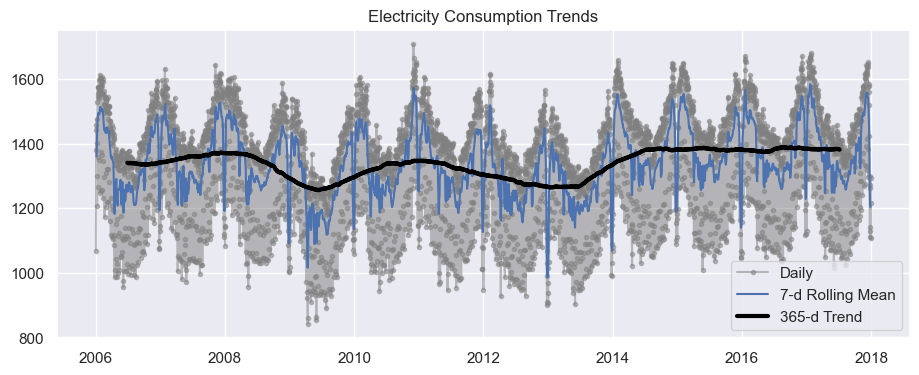

In [6]:
# --- 5. Rolling Windows (Smoothing Trends) ---
# 7-day and 365-day rolling mean

opsd_7d = opsd_daily[data_columns].rolling(7, center=True).mean()
opsd_365d = opsd_daily[data_columns].rolling(window=365, center=True, min_periods=360).mean()

# Plotting the Trend

plt.figure()
plt.plot(opsd_daily['Consumption'], marker='.', alpha=0.5, label='Daily', color='gray')
plt.plot(opsd_7d['Consumption'], label='7-d Rolling Mean')
plt.plot(opsd_365d['Consumption'], color='black', linewidth=3, label='365-d Trend')
plt.legend()
plt.title('Electricity Consumption Trends')
plt.show()